**Neural Networks**
------------------

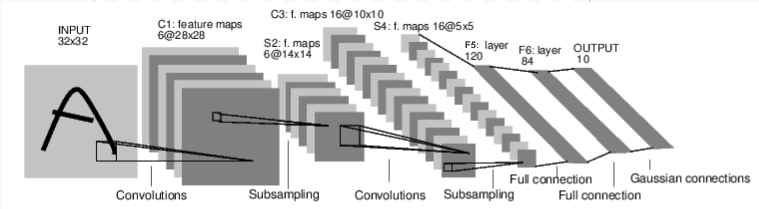

A typical training procedure for a neural network is as follows:

- Define the neural network that has some learnable parameters (or
  weights)
- Iterate over a dataset of inputs
- Process input through the network
- Compute the loss (how far is the output from being correct)
- Propagate gradients back into the network’s parameters
- Update the weights of the network, typically using a simple update rule:

\begin{align}weight = weight - learningRate * gradient\end{align}


# Define the network
------------------

Let’s define this network:


In [31]:
import torch
import torch.nn as nn
import torch.nn.functional as F
print(torch.__version__)

2.7.0+cu118


We want to be able to train our model on a hardware accelerator like the GPU or MPS, if available. 

Let’s check to see if ``torch.cuda`` or ``torch.backends.mps`` are available, otherwise we use the CPU.

In [32]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cpu device


# NN Components
**let us examine the component layers of NN**

## Module

In [22]:
nn.Module?

Init signature: nn.Module(*args, **kwargs) -> None
Docstring:     
Base class for all neural network modules.

Your models should also subclass this class.

Modules can also contain other Modules, allowing them to be nested in
a tree structure. You can assign the submodules as regular attributes::

    import torch.nn as nn
    import torch.nn.functional as F

    class Model(nn.Module):
        def __init__(self) -> None:
            super().__init__()
            self.conv1 = nn.Conv2d(1, 20, 5)
            self.conv2 = nn.Conv2d(20, 20, 5)

        def forward(self, x):
            x = F.relu(self.conv1(x))
            return F.relu(self.conv2(x))

Submodules assigned in this way will be registered, and will also have their
parameters converted when you call :meth:`to`, etc.

.. note::
    As per the example above, an ``__init__()`` call to the parent class
    must be made before assignment on the child.

:ivar training: Boolean represents whether this module is in training or
    

### Layers

#### Linear

In [14]:
nn.Linear??

Init signature:
nn.Linear(
    in_features: int,
    out_features: int,
    bias: bool = True,
    device=None,
    dtype=None,
) -> None
Source:        
class Linear(Module):
    r"""Applies an affine linear transformation to the incoming data: :math:`y = xA^T + b`.

    This module supports :ref:`TensorFloat32<tf32_on_ampere>`.

    On certain ROCm devices, when using float16 inputs this module will use :ref:`different precision<fp16_on_mi200>` for backward.

    Args:
        in_features: size of each input sample
        out_features: size of each output sample
        bias: If set to ``False``, the layer will not learn an additive bias.
            Default: ``True``

    Shape:
        - Input: :math:`(*, H_\text{in})` where :math:`*` means any number of
          dimensions including none and :math:`H_\text{in} = \text{in\_features}`.
        - Output: :math:`(*, H_\text{out})` where all but the last dimension
          are the same shape as the input and :math:`H_\text{out} = \t

``torch.empty()`` is a PyTorch function that returns a tensor filled with uninitialized data.

This means that memory is allocated for the tensor, but its values are not set to any specific initial state (like zeros or random numbers). 

The content of an empty tensor will be whatever data was **already present in the allocated memory block** before it was assigned to the tensor.

In [4]:
torch.empty?

Docstring:
empty(*size, *, out=None, dtype=None, layout=torch.strided, device=None, requires_grad=False, pin_memory=False, memory_format=torch.contiguous_format) -> Tensor

Returns a tensor filled with uninitialized data. The shape of the tensor is
defined by the variable argument :attr:`size`.

.. note::
    If :func:`torch.use_deterministic_algorithms()` and
    :attr:`torch.utils.deterministic.fill_uninitialized_memory` are both set to
    ``True``, the output tensor is initialized to prevent any possible
    nondeterministic behavior from using the data as an input to an operation.
    Floating point and complex tensors are filled with NaN, and integer tensors
    are filled with the maximum value.

Args:
    size (int...): a sequence of integers defining the shape of the output tensor.
        Can be a variable number of arguments or a collection like a list or tuple.

Keyword args:
    out (Tensor, optional): the output tensor.
    dtype (:class:`torch.dtype`, optional): the desi

In [6]:
print(torch.empty(2,3))

tensor([[1.3114e+05, 1.5989e-42, 0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00]])


In [23]:
torch.nn.Parameter?

Init signature: torch.nn.Parameter(data=None, requires_grad=True)
Docstring:     
A kind of Tensor that is to be considered a module parameter.

Parameters are :class:`~torch.Tensor` subclasses, that have a
very special property when used with :class:`Module` s - when they're
assigned as Module attributes they are automatically added to the list of
its parameters, and will appear e.g. in :meth:`~Module.parameters` iterator.
Assigning a Tensor doesn't have such effect. This is because one might
want to cache some temporary state, like last hidden state of the RNN, in
the model. If there was no such class as :class:`Parameter`, these
temporaries would get registered too.

Args:
    data (Tensor): parameter tensor.
    requires_grad (bool, optional): if the parameter requires gradient. Note that
        the torch.no_grad() context does NOT affect the default behavior of
        Parameter creation--the Parameter will still have `requires_grad=True` in
        :class:`~no_grad` mode. See :r

Notice in ``nn.Parameter`` the default ``requires_grad=True``

**Example on ``Linear``:**

In [10]:
input = torch.rand(3,2,4) # C x H x W
print("input:")
print(input)

LinearLayer=nn.Linear(in_features=4, out_features=3, bias=True)

print("\n Linear:")
print(LinearLayer)

print("\n LinearLayer weights:")
print(LinearLayer.weight)

print("\n bias:")
print(LinearLayer.bias)

out = LinearLayer(input)
print(out.size())
print("out:")
print(out)

input:
tensor([[[0.9627, 0.2130, 0.3529, 0.7094],
         [0.5915, 0.6743, 0.3865, 0.1572]],

        [[0.7980, 0.8632, 0.7479, 0.8507],
         [0.9394, 0.3381, 0.3685, 0.6142]],

        [[0.0599, 0.7321, 0.7365, 0.7559],
         [0.4990, 0.7659, 0.1629, 0.8732]]])

 Linear:
Linear(in_features=4, out_features=3, bias=True)

 LinearLayer weights:
Parameter containing:
tensor([[ 0.0680, -0.2941,  0.3342,  0.3138],
        [ 0.3235, -0.3617, -0.2971, -0.3827],
        [-0.4122,  0.2690,  0.4998,  0.2734]], requires_grad=True)

 bias:
Parameter containing:
tensor([-0.1635,  0.0906,  0.1128], requires_grad=True)
torch.Size([3, 2, 3])
out:
tensor([[[ 0.1798, -0.0513,  0.1436],
         [-0.1431, -0.1369,  0.2865]],

        [[ 0.1538, -0.5111,  0.6225],
         [ 0.1168, -0.0723,  0.1687]],

        [[ 0.1086, -0.6628,  0.8598],
         [-0.0264, -0.4075,  0.4333]]], grad_fn=<ViewBackward0>)


#### Convolutional Layer

In [18]:
nn.Conv2d?

Init signature:
nn.Conv2d(
    in_channels: int,
    out_channels: int,
    kernel_size: Union[int, tuple[int, int]],
    stride: Union[int, tuple[int, int]] = 1,
    padding: Union[str, int, tuple[int, int]] = 0,
    dilation: Union[int, tuple[int, int]] = 1,
    groups: int = 1,
    bias: bool = True,
    padding_mode: str = 'zeros',
    device=None,
    dtype=None,
) -> None
Docstring:     
Applies a 2D convolution over an input signal composed of several input
planes.

In the simplest case, the output value of the layer with input size
:math:`(N, C_{\text{in}}, H, W)` and output :math:`(N, C_{\text{out}}, H_{\text{out}}, W_{\text{out}})`
can be precisely described as:

.. math::
    \text{out}(N_i, C_{\text{out}_j}) = \text{bias}(C_{\text{out}_j}) +
    \sum_{k = 0}^{C_{\text{in}} - 1} \text{weight}(C_{\text{out}_j}, k) \star \text{input}(N_i, k)


where :math:`\star` is the valid 2D `cross-correlation`_ operator,
:math:`N` is a batch size, :math:`C` denotes a number of channels,
:

**Example on ``Conv2d``:**

In [24]:
input = torch.rand(1,4,4)
print("input:")
print(input)

convLayer=nn.Conv2d(in_channels=1, out_channels=1, kernel_size = 2, stride=1, bias=True)

print("\n kernel_size:") 
print(convLayer.kernel_size)

print("\n convLayer:")
print(convLayer)

print("\n convLayer weights:")
print(convLayer.weight)

print("\n bias:")
print(convLayer.bias)

twoD_out = convLayer(input)
print(twoD_out.size())
print("twoD_out:")
print(twoD_out)

input:
tensor([[[0.2893, 0.7758, 0.0422, 0.8952],
         [0.2034, 0.8866, 0.6023, 0.4857],
         [0.1674, 0.9476, 0.5699, 0.6212],
         [0.6267, 0.7165, 0.9150, 0.7907]]])

 kernel_size:
(2, 2)

 convLayer:
Conv2d(1, 1, kernel_size=(2, 2), stride=(1, 1))

 convLayer weights:
Parameter containing:
tensor([[[[-0.4634,  0.3589],
          [-0.1625,  0.3114]]]], requires_grad=True)

 bias:
Parameter containing:
tensor([0.1201], requires_grad=True)
torch.Size([1, 3, 3])
twoD_out:
tensor([[[ 0.5075, -0.1808,  0.4752],
         [ 0.6119, -0.0512,  0.1162],
         [ 0.5039,  0.0540,  0.1765]]], grad_fn=<SqueezeBackward1>)


### Pooling

In [31]:
F.max_pool2d??

Signature: F.max_pool2d(*args, **kwargs)
Docstring:
max_pool2d(input, kernel_size, stride=None, padding=0, dilation=1, ceil_mode=False, return_indices=False)

Applies a 2D max pooling over an input signal composed of several input
planes.

.. note::
    The order of :attr:`ceil_mode` and :attr:`return_indices` is different from
    what seen in :class:`~torch.nn.MaxPool2d`, and will change in a future release.

See :class:`~torch.nn.MaxPool2d` for details.

Args:
    input: input tensor :math:`(\text{minibatch} , \text{in\_channels} , iH , iW)`, minibatch dim optional.
    kernel_size: size of the pooling region. Can be a single number or a
        tuple `(kH, kW)`
    stride: stride of the pooling operation. Can be a single number or a
        tuple `(sH, sW)`. Default: :attr:`kernel_size`
    padding: Implicit negative infinity padding to be added on both sides, must be >= 0 and <= kernel_size / 2.
    dilation: The stride between elements within a sliding window, must be > 0.
    ce

**Example on ``max_pool2d``:**

In [25]:
x = F.max_pool2d(twoD_out, kernel_size=2, stride=1, padding=0, dilation=1, ceil_mode=False, return_indices=False)
print(x)

tensor([[[0.6119, 0.4752],
         [0.6119, 0.1765]]], grad_fn=<MaxPool2DWithIndicesBackward0>)


### Activation Functions

#### Rectified Linear Unit (ReLU)**

<img src="Relu-activation-function.png" width="500">

In [22]:
F.relu??

Signature: F.relu(input: torch.Tensor, inplace: bool = False) -> torch.Tensor
Source:   
def relu(input: Tensor, inplace: bool = False) -> Tensor:  # noqa: D400,D402
    r"""relu(input, inplace=False) -> Tensor

    Applies the rectified linear unit function element-wise. See
    :class:`~torch.nn.ReLU` for more details.
    """
    if has_torch_function_unary(input):
        return handle_torch_function(relu, (input,), input, inplace=inplace)
    if inplace:
        result = torch.relu_(input)
    else:
        result = torch.relu(input)
    return result
File:      c:\python\python3\lib\site-packages\torch\nn\functional.py
Type:      function

**Example on ``relu``:**

In [26]:
relu = F.relu (twoD_out)
print(relu)

tensor([[[0.5075, 0.0000, 0.4752],
         [0.6119, 0.0000, 0.1162],
         [0.5039, 0.0540, 0.1765]]], grad_fn=<ReluBackward0>)


## `tensor.view()` function 
returns the a new tensor with the same data as the self tensor but with different shape

In PyTorch, the **`tensor.view(*shape)`** method is used to **reshape a tensor without copying its underlying data**.

It creates a new tensor object that points to the exact same memory block as the original tensor, making it an extremely fast and memory-efficient operation.

### ⚙️ Key Mechanics

* **Shared Memory:** Because it shares memory with the original tensor, any modification you make to the reshaped tensor will immediately change the original tensor.
* **Element Count:** The new shape must have the exact same total number of elements as the original tensor (e.g., a \(2x3\) tensor has \(6\) elements and can be viewed as \(1x6\), \(3x2\), or \(6x1\)).
* **The `-1` Shortcut:** You can pass `-1` for **one** of the dimensions, and PyTorch will automatically calculate the correct size for that dimension based on the remaining elements.

https://docs.pytorch.org/docs/2.14/generated/torch.Tensor.view.html


In [27]:
# ==========================================
# 1. BASIC RESHAPING & THE -1 SHORTCUT
# ==========================================
print("--- 1. Basic Reshaping ---")
original = torch.arange(6) # Creates [0, 1, 2, 3, 4, 5]
print(f"Original shape: {original.shape}")

# Reshape to a 2x3 matrix
matrix = original.view(2, 3)
print(f"2x3 View:\n{matrix}")

# Flatten back using -1
flattened = matrix.view(-1)
print(f"Flattened view (-1) shape: {flattened.shape}\n")


--- 1. Basic Reshaping ---
Original shape: torch.Size([6])
2x3 View:
tensor([[0, 1, 2],
        [3, 4, 5]])
Flattened view (-1) shape: torch.Size([6])



In [19]:
x= torch.rand(2,4)
print(x.size())

#y = x.view(8)
#y = x.view((8,1))
y = x.view((4,2))
print(x)

print(y)

torch.Size([2, 4])
tensor([[0.7105, 0.1504, 0.7435, 0.0555],
        [0.7067, 0.6649, 0.1739, 0.3944]])
tensor([[0.7105, 0.1504],
        [0.7435, 0.0555],
        [0.7067, 0.6649],
        [0.1739, 0.3944]])


#### Softmax
The softmax function is a mathematical operation used in machine learning, particularly in the output layer of neural networks, to convert a vector of raw scores (logits) into a probability distribution. It produces a vector of probabilities, where each probability is between 0 and 1, and the sum of all probabilities equals 1. 

This function is crucial for multiclass classification tasks, as it provides the model's confidence for each possible outcome.

It is commonly used as an activation function in the output layer of deep learning models for multiclass classification.

<center>$\text{Softmax}(x_{i}) = \frac{\exp(x_i)}{\sum_j \exp(x_j)}$</center>



<img src="Softmax_Function.png" width="300">

In [16]:
nn.Softmax?

Init signature: nn.Softmax(dim: Optional[int] = None) -> None
Docstring:     
Applies the Softmax function to an n-dimensional input Tensor.

Rescales them so that the elements of the n-dimensional output Tensor
lie in the range [0,1] and sum to 1.

Softmax is defined as:

.. math::
    \text{Softmax}(x_{i}) = \frac{\exp(x_i)}{\sum_j \exp(x_j)}

When the input Tensor is a sparse tensor then the unspecified
values are treated as ``-inf``.

Shape:
    - Input: :math:`(*)` where `*` means, any number of additional
      dimensions
    - Output: :math:`(*)`, same shape as the input

Returns:
    a Tensor of the same dimension and shape as the input with
    values in the range [0, 1]

Args:
    dim (int): A dimension along which Softmax will be computed (so every slice
        along dim will sum to 1).

.. note::
    This module doesn't work directly with NLLLoss,
    which expects the Log to be computed between the Softmax and itself.
    Use `LogSoftmax` instead (it's faster and has bett

**Example on ``Softmax``:**

In [17]:
softmax = nn.Softmax(dim=1)
print(softmax)
outSoftmax = softmax(twoD_out)
print(twoD_out)
print("outSoftmax:")
print(outSoftmax)

Softmax(dim=1)
tensor([[[-0.2653, -0.1560,  0.0984],
         [-0.2114, -0.1194,  0.0240],
         [ 0.0195, -0.2111, -0.2082]]], grad_fn=<SqueezeBackward1>)
outSoftmax:
tensor([[[0.2954, 0.3352, 0.3753],
         [0.3118, 0.3476, 0.3484],
         [0.3928, 0.3172, 0.2762]]], grad_fn=<SoftmaxBackward0>)


# Build our NN

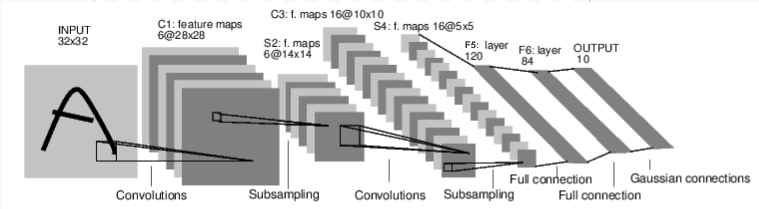

**let us build a network using these types of layers:**

In [35]:
#import torch
#import torch.nn as nn
#import torch.nn.functional as F

class Net(nn.Module):

    def __init__(self):
        super(Net, self).__init__() 
        # 1 input image channel, 6 output channels, 3x3 square convolution
        # kernel
        self.conv1 = nn.Conv2d(1, 6, 3)  # first convolutional layer: Extracts 6 feature maps using 3x3 filters from the 1 input channel.
        self.conv2 = nn.Conv2d(6, 16, 3)  # sencond convolutional layer: Takes the 6 feature maps and outputs 16 feature maps using 3x3 filters
        # an affine operation: y = Wx + b
        self.fc1 = nn.Linear(16 * 6* 6, 120)  # 5*5 from image dimension, 16 for channels
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):

        # Apply ReLU activation to conv1's output, then downsamples spatial dimensions by half using 2x2 Max Pooling.
        x = F.max_pool2d(F.relu(self.conv1(x)), (2, 2)) # Max pooling over a (2, 2) window
        
        # Apply ReLU activation to conv2's output, followed by another 2x2 Max Pooling.
        x = F.max_pool2d(F.relu(self.conv2(x)), 2) # If the size is a square you can only specify a single number

        # Flattens the spatial feature maps (16x5x5) into a 1D vector of size 400 per sample while keeping the batch dimension intact.
        x = x.view(-1, self.num_flat_features(x))
        print(x.size())
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

    def num_flat_features(self, x):
        size = x.size()[1:]  # all dimensions except the batch dimension
        num_features = 1
        for s in size:
            num_features *= s
        return num_features


net = Net()
print(net)

Net(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=576, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


**You just have to define the ``forward`` function, and the ``backward``
function (where gradients are computed) is automatically defined for you
using ``autograd``.
You can use any of the Tensor operations in the ``forward`` function.**

**The learnable parameters of a model are returned by ``net.parameters()``**

In [29]:
params = list(net.parameters())
#print(params) #printing the weights (elements of all the kernels)
print("parm length:", len(params))
print(params[0].size())  # conv1's .weight
print(params[6].size())  # .weight

parm length: 10
torch.Size([6, 1, 3, 3])
torch.Size([84, 120])


In PyTorch, you can easily access and print the weights of a specific layer in your neural network.
Let us print the weights of the convolutional layer named conv2:

**Note:** The weights before training are got from the empty function (Returns a tensor filled with uninitialized data.)

In [29]:
print("\n Conv1 kernel_size:") 
print(net.conv1.kernel_size)

print("\n Conv1 bias:")
print(net.conv1.bias)

print("\nConv1 Weights:")
print(net.conv1.weight)



 Conv1 kernel_size:
(3, 3)

 Conv1 bias:
Parameter containing:
tensor([-0.3313, -0.2634,  0.1835, -0.1824, -0.0397, -0.1344],
       requires_grad=True)

Conv1 Weights:
Parameter containing:
tensor([[[[ 0.1290,  0.2938,  0.1855],
          [ 0.2899, -0.1816, -0.3029],
          [-0.0710,  0.2944, -0.2610]]],


        [[[-0.2440, -0.0453, -0.2697],
          [ 0.1580,  0.0722, -0.3308],
          [ 0.1174, -0.0416, -0.2792]]],


        [[[-0.0820, -0.0473,  0.2899],
          [ 0.2974, -0.2465, -0.0011],
          [ 0.0147,  0.1420,  0.1585]]],


        [[[-0.2481,  0.0717,  0.3091],
          [ 0.2631, -0.3097,  0.1358],
          [ 0.2912, -0.1161, -0.1862]]],


        [[[-0.2927,  0.2206, -0.0710],
          [ 0.3076, -0.2207, -0.0923],
          [-0.0222, -0.0496,  0.3176]]],


        [[[-0.1368,  0.2265,  0.1924],
          [ 0.0988, -0.1429, -0.1861],
          [ 0.2485,  0.2050, -0.3112]]]], requires_grad=True)


**Let's try a random 32x32 input.**

**Note: expected input size of this net (Net) is 32x32. To use this net on
the MNIST dataset, please resize the images from the dataset to 32x32.**

In [36]:
input = torch.randn(1, 1, 32, 32) # creat the input as tensor that contains random variables
print(input)
out = net(input) # pass the 
print(out)

tensor([[[[-0.8824, -2.1650,  1.2587,  ...,  0.8919, -0.5467,  1.3062],
          [ 1.8539,  1.0092,  1.5736,  ...,  0.6621, -1.2760, -0.1404],
          [-1.0512,  0.9990,  0.2753,  ..., -0.2651, -0.7269,  0.1726],
          ...,
          [ 0.5923, -0.9399, -1.0470,  ...,  0.8715,  1.6541, -0.3606],
          [ 0.3316,  1.8981, -0.1789,  ...,  0.5417, -0.9727,  1.1999],
          [-0.4974,  0.8494,  1.9240,  ..., -0.8898, -0.9322, -0.1567]]]])
torch.Size([1, 576])
tensor([[ 0.0450,  0.0138,  0.0374, -0.0089,  0.1013,  0.1092,  0.0827, -0.0355,
          0.0504,  0.0342]], grad_fn=<AddmmBackward0>)


**The graph of computations that looks like this:**

input -> conv2d -> relu -> maxpool2d -> conv2d -> relu -> maxpool2d
      -> view -> linear -> relu -> linear -> relu -> linear

**Zero the gradient buffers of all parameters and backprops with random
gradients:**

In [5]:
net.zero_grad()
out.backward(torch.randn(1, 10))

### NOTE: 
`torch.nn` only supports mini-batches. The entire `torch.nn`
    package only supports inputs that are a mini-batch of samples, and not
    a single sample. 
    
For example, `nn.Conv2d` will take in a 4D Tensor of `nSamples x nChannels x Height x Width`.

If you have a single sample, just use `input.unsqueeze(0)` to add a fake batch dimension.
    __________________________________________________________________________________________________

Before proceeding further, let's recap all the classes you’ve seen so far.

**Recap:**
  -  ``torch.Tensor`` - A *multi-dimensional array* with support for autograd
     operations like ``backward()``. Also *holds the gradient* w.r.t. the
     tensor.
  -  ``nn.Module`` - Neural network module. *Convenient way of
     encapsulating parameters*, with helpers for moving them to GPU,
     exporting, loading, etc.
  -  ``nn.Parameter`` - A kind of Tensor, that is *automatically
     registered as a parameter when assigned as an attribute to a*
     ``Module``.
  -  ``autograd.Function`` - Implements *forward and backward definitions
     of an autograd operation*. Every ``Tensor`` operation creates at
     least a single ``Function`` node that connects to functions that
     created a ``Tensor`` and *encodes its history*.

**At this point, we covered:**
  -  Defining a neural network
  -  Processing inputs and calling backward

**Still Left:**
  -  Computing the loss
  -  Updating the weights of the network

## Loss Function

A loss function takes the (output, target) pair of inputs, and computes a
value that estimates how far away the output is from the target.

There are several different
[loss functions] (https://pytorch.org/docs/nn.html#loss-functions)  under the
nn package.
A simple loss is: ``nn.MSELoss`` which computes the mean-squared error
between the input and the target.

For example:



In [37]:
output = net(input)
print(output)
target = torch.randn(10)  # a dummy target, for example
print(target)
target = target.view(1, -1)  # make it the same shape as output

criterion = nn.MSELoss()

loss = criterion(output, target)
print(loss)

torch.Size([1, 576])
tensor([[ 0.0450,  0.0138,  0.0374, -0.0089,  0.1013,  0.1092,  0.0827, -0.0355,
          0.0504,  0.0342]], grad_fn=<AddmmBackward0>)
tensor([ 0.9196, -1.6290, -0.3658, -1.3563,  1.5198,  1.6486,  0.2330,  1.9973,
         0.4228, -0.9486])
tensor(1.5083, grad_fn=<MseLossBackward0>)


Now, if you follow ``loss`` in the backward direction, using its
``.grad_fn`` attribute, you will see a graph of computations that looks
like this:

::

    input -> conv2d -> relu -> maxpool2d -> conv2d -> relu -> maxpool2d
          -> view -> linear -> relu -> linear -> relu -> linear
          -> MSELoss
          -> loss

So, when we call ``loss.backward()``, the whole graph is differentiated
w.r.t. the loss, and all Tensors in the graph that has ``requires_grad=True``
will have their ``.grad`` Tensor accumulated with the gradient.

For illustration, let us follow a few steps backward:

In [33]:
print(loss.grad_fn)  # MSELoss
print(loss.grad_fn.next_functions[0][0])  # Linear
print(loss.grad_fn.next_functions[0][0].next_functions[0][0])  # ReLU

Backprop
--------
To backpropagate the error all we have to do is to ``loss.backward()``.
You need to clear the existing gradients though, else gradients will be
accumulated to existing gradients.


Now we shall call ``loss.backward()``, and have a look at conv1's bias
gradients before and after the backward.


In [38]:
print('conv1.bias.grad before zeroing')
print(net.conv1.bias.grad)

print('conv1.weight.grad before zeroing')
print(net.conv1.weight.grad)

net.zero_grad()     # zeroes the gradient buffers of all parameters

print('conv1.bias.grad before backward')
print(net.conv1.bias.grad)

print('conv1.bias.weight before backward')
print(net.conv1.weight.grad)

loss.backward()

print('conv1.bias.grad after backward')
print(net.conv1.bias.grad)


print('conv1.bias.weight after backward')
print(net.conv1.weight.grad)


conv1.bias.grad before zeroing
None
conv1.weight.grad before zeroing
None
conv1.bias.grad before backward
None
conv1.bias.weight before backward
None
conv1.bias.grad after backward
tensor([-0.0066,  0.0211,  0.0038,  0.0099, -0.0087,  0.0078])
conv1.bias.weight after backward
tensor([[[[ 7.5231e-03, -1.1334e-02, -1.5436e-02],
          [ 1.2743e-02,  2.1298e-02,  4.0464e-05],
          [-9.5376e-04,  1.2942e-02,  6.2328e-03]]],


        [[[-2.3338e-02, -8.6890e-03,  1.0686e-03],
          [ 3.5858e-03,  7.9268e-03, -5.1572e-03],
          [ 1.3783e-02, -1.1226e-02,  3.3700e-03]]],


        [[[-1.9438e-03,  9.0722e-03, -8.7982e-03],
          [ 1.0918e-02,  1.2950e-02,  6.8418e-03],
          [ 8.3521e-03,  3.9934e-02, -2.1536e-02]]],


        [[[-1.1712e-02,  1.3980e-02,  1.3366e-02],
          [-1.5130e-02, -5.0590e-04, -1.0763e-02],
          [-1.3864e-02,  4.5343e-03,  2.4161e-02]]],


        [[[ 5.5246e-04,  1.7974e-02,  2.7057e-04],
          [ 8.8358e-03,  2.1641e-03,  1.6299

Now, we have seen how to use loss functions.

**Read Later:**

  The neural network package contains various modules and loss functions
  that form the building blocks of deep neural networks. A full list with
  documentation is [here] (https://pytorch.org/docs/nn).

**The only thing left to learn is:**

  - Updating the weights of the network

Update the weights
------------------
The simplest update rule used in practice is the Stochastic Gradient
Descent (SGD):

\begin{align}weight = weight - learningRate * gradient\end{align}

We can implement this using simple Python code:


    learning_rate = 0.01
    for f in net.parameters():
        f.data.sub_(f.grad.data * learning_rate)

However, as you use neural networks, you want to use various different
update rules such as SGD, Nesterov-SGD, Adam, RMSProp, etc.
To enable this, we built a small package: ``torch.optim`` that
implements all these methods. Using it is very simple:

In [39]:
import torch.optim as optim

# create your optimizer
optimizer = optim.SGD(net.parameters(), lr=0.01) 

# in your training loop:
optimizer.zero_grad()   # zero the gradient buffers
output = net(input)
loss = criterion(output, target)
loss.backward()

# print the bias and weights before update
print("\n Conv1 bias before update:")
print(net.conv1.bias)

print("\nConv1 Weights before update:")
print(net.conv1.weight.data)

optimizer.step()    # Does the update

# print the bias and weights after update
print("\n Conv1 bias after update:")
print(net.conv1.bias)

print("\nConv1 Weights after update:")
print(net.conv1.weight.data)

torch.Size([1, 576])

 Conv1 bias before update:
Parameter containing:
tensor([-0.1379,  0.0667,  0.2438,  0.0934, -0.0683, -0.2877],
       requires_grad=True)

Conv1 Weights before update:
tensor([[[[ 0.0576, -0.0288,  0.3213],
          [ 0.2307,  0.1345, -0.1940],
          [ 0.0896, -0.2078, -0.1147]]],


        [[[-0.2971,  0.1522, -0.0209],
          [ 0.3008,  0.2451, -0.3120],
          [ 0.0181, -0.1502,  0.0799]]],


        [[[ 0.0608,  0.1887,  0.0838],
          [ 0.1289,  0.0240, -0.1167],
          [ 0.2863,  0.2222,  0.0815]]],


        [[[-0.0738,  0.2562,  0.2674],
          [ 0.1158, -0.0637, -0.2825],
          [-0.2608, -0.2430,  0.0077]]],


        [[[-0.0401,  0.3232, -0.1936],
          [ 0.1527, -0.1795, -0.0601],
          [-0.1130,  0.3258, -0.0133]]],


        [[[ 0.1754,  0.0127,  0.0321],
          [-0.0592, -0.1520,  0.2444],
          [-0.2414,  0.0237,  0.1390]]]])

 Conv1 bias after update:
Parameter containing:
tensor([-0.1379,  0.0664,  0.2438, 

In [37]:
import torch.optim as optim

# create your optimizer
optimizer = optim.Adam(net.parameters(), lr=0.01) 

# in your training loop:
optimizer.zero_grad()   # zero the gradient buffers
output = net(input)
loss = criterion(output, target)
loss.backward()
optimizer.step()    # Does the update

torch.Size([1, 576])


**You have seen how to define neural networks, compute loss and make updates to the weights of the network.
One thing is still missing:**

## Input Data


Generally, when you have to deal with image, text, audio or video data,
you can use standard python packages that load data into a numpy array.
Then you can convert this array into a ``torch.*Tensor``.

-  For images, packages such as Pillow, OpenCV are useful
-  For audio, packages such as scipy and librosa
-  For text, either raw Python or Cython based loading, or NLTK and
   SpaCy are useful


**Let us show our training images, for fun!**

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image

In [42]:
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    print("img:")
    print(img)
    npimg = img.numpy()
    print("npimg:")
    print(npimg)
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.2865686..2.7672138].


tensor([[[[-0.8824, -2.1650,  1.2587,  ...,  0.8919, -0.5467,  1.3062],
          [ 1.8539,  1.0092,  1.5736,  ...,  0.6621, -1.2760, -0.1404],
          [-1.0512,  0.9990,  0.2753,  ..., -0.2651, -0.7269,  0.1726],
          ...,
          [ 0.5923, -0.9399, -1.0470,  ...,  0.8715,  1.6541, -0.3606],
          [ 0.3316,  1.8981, -0.1789,  ...,  0.5417, -0.9727,  1.1999],
          [-0.4974,  0.8494,  1.9240,  ..., -0.8898, -0.9322, -0.1567]]]])
img:
tensor([[[ 0.0588, -0.5825,  1.1293,  ...,  0.9459,  0.2266,  1.1531],
         [ 1.4270,  1.0046,  1.2868,  ...,  0.8310, -0.1380,  0.4298],
         [-0.0256,  0.9995,  0.6376,  ...,  0.3675,  0.1365,  0.5863],
         ...,
         [ 0.7962,  0.0300, -0.0235,  ...,  0.9358,  1.3271,  0.3197],
         [ 0.6658,  1.4491,  0.4105,  ...,  0.7708,  0.0136,  1.0999],
         [ 0.2513,  0.9247,  1.4620,  ...,  0.0551,  0.0339,  0.4217]],

        [[ 0.0588, -0.5825,  1.1293,  ...,  0.9459,  0.2266,  1.1531],
         [ 1.4270,  1.0046,  1.2

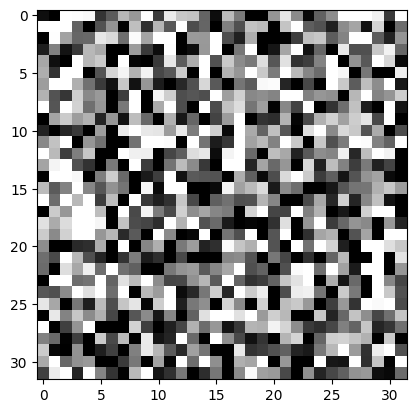

In [43]:
import torch
import torchvision
print(input)

image = torchvision.utils.make_grid(input)
imshow(image)